**Running on Colab?** Just run the setup cell below. It clones the repo and installs the package. For a free GPU: Runtime → Change runtime type → GPU.

In [ ]:
# --- Colab setup (auto-injected by build_notebooks.py; do not edit the .ipynb) ---
import os, sys, subprocess

if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != "tutorials":
    # Clone the repo (this also brings calibration.py and the data/ reference
    # files the notebooks load) and install the package.
    if not os.path.isdir("SRL"):
        url = "https://github.com/StructuralRL/SRL.git"
        subprocess.run(["git", "clone", "--depth=1", url, "SRL"], check=True)
    os.chdir("SRL/tutorials_new")
    sys.path.insert(0, os.getcwd())

# 0. The household problem, the way you already solve it

This is the starting point of the SRL tutorials, and it contains nothing new,
on purpose. We solve a model you have almost certainly coded yourself, the
income-fluctuation (consumption–savings) problem, with a method you know cold:
value function iteration (VFI). Plain NumPy, no JAX, no `srl`.

Why begin here? The rest of the course introduces two new things, JAX (the
tooling, notebook 1) and the policy gradient (the method, notebook 2), and the
only way to *trust* them is to check them against an answer you already
believe. This notebook produces that answer. Notebooks 1 and 2 solve the
*same* model a different way and must land on the *same* consumption policy.

These first notebooks are **partial equilibrium**: the household takes the
interest rate as given. There's no market clearing yet, and we don't look at
the wealth distribution; that comes in notebook 4, where it's actually used.

## What you should already know

- The consumption–savings problem with idiosyncratic income risk and a
  borrowing constraint.
- Value function iteration: iterating the Bellman operator to a fixed point.

No JAX, no reinforcement learning. If you have solved an Aiyagari household
block, you are over-qualified for this notebook.

## The model

A household chooses consumption $c$ and next-period bonds $b'$ to maximize
$$\mathbb{E}_0 \sum_{t=0}^\infty \beta^t\, u(c_t),
  \qquad u(c)=\frac{c^{1-\sigma}}{1-\sigma},$$
subject to the budget constraint and a no-borrowing limit
$$c + q\,b' = b + y, \qquad b' \ge 0.$$
Here $y$ is idiosyncratic labor income (a Markov chain) and $q$ is the **bond
price**: buying $b'$ bonds costs $q\,b'$ today and pays $b'$ next period, so
the gross interest rate is $1/q = 1+r$. Following Huggett (1993) we work in the
bond price $q$; the interest rate is just $r = 1/q - 1$. In these first
notebooks $q$ is **fixed** at a value just below its general-equilibrium level
(the market sets it in notebook 4).

We parameterize the choice by the **consumption share** $s \in [0,1]$: consume
$c = s\,(b+y)$ and save the rest, $b' = (b + y - c)/q$. The Bellman equation is
$$V(b,y) = \max_{s\in[0,1]}\ u\!\big(s\,(b+y)\big)
           + \beta \sum_{y'} \Pi(y'\mid y)\, V(b', y'),$$
solved by value function iteration.

## Calibration

One parameterization is shared across the whole tutorial sequence, so every
notebook describes the same economy. It lives in `calibration.py` (pure NumPy):
the income process is a 3-state **Rouwenhorst** discretization of a log-AR(1)
($\rho=0.966$, stationary log-std $0.5$, mean income 1), and the asset grid is
the standard geometric grid, dense near the borrowing constraint.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from calibration import SIGMA, BETA, Q_FIXED, asset_grid, rouwenhorst

sigma, beta, q = SIGMA, BETA, Q_FIXED
e_grid, Pi = rouwenhorst()            # income levels and transition matrix
n_y = e_grid.size

n_b = 100                             # asset-grid points
n_share = 2000                        # consumption shares searched at each state
eps = 1e-9                            # consumption floor (keeps utility finite)
b_grid = asset_grid(n_b)

print(f"interest rate  r = 1/q - 1 = {1 / q - 1:.4%}")
print("income states:", e_grid.round(3))

interest rate  r = 1/q - 1 = 0.5025%
income states: [0.436 0.885 1.794]


## Value function iteration

This is exactly the value-function iteration the library's `VFISolver` runs,
iterating the Bellman operator to a fixed point, just written out in plain
NumPy so every step is visible. (Notebook 1 confirms `VFISolver` lands on the
same answer.) The household may choose *any* $b'$, not only a grid point, so we
evaluate the continuation value $V(b',y')$ by linear interpolation on the
asset grid, searching over a fine grid of consumption shares $s\in[0,1]$.

In [3]:
%%time

def crra(c, sig):
    feasible = c > eps
    cc = np.maximum(c, eps)
    u = np.log(cc) if sig == 1.0 else (cc ** (1 - sig)) / (1 - sig)   # sigma=1 is log utility
    return np.where(feasible, u, -1e12)


def solve_vfi(sig=sigma, tol=1e-9, max_iter=5000):
    """Value function iteration. Returns V and the consumption policy (n_b, n_y)."""
    shares = np.linspace(0.0, 1.0, n_share)
    wealth = b_grid[:, None] + e_grid[None, :]                       # cash on hand (n_b, n_y)

    # Consumption, next assets and flow utility for every (b, y, share):
    c = np.clip(wealth[:, :, None] * shares, eps, wealth[:, :, None] - eps)
    b_next = (wealth[:, :, None] - c) / q                            # (n_b, n_y, n_share)
    flow = crra(c, sig)

    V = np.zeros((n_b, n_y))
    for it in range(max_iter):
        # E[V(b', y') | y]: interpolate V onto b' for each next-income y',
        # then average over y' with the transition matrix.
        V_next = np.stack([np.interp(b_next, b_grid, V[:, yp]) for yp in range(n_y)], axis=-1)
        EV = (V_next * Pi[None, :, None, :]).sum(axis=-1)            # (n_b, n_y, n_share)
        objective = flow + beta * EV
        V_new = objective.max(axis=2)                                # Bellman: best share
        if np.abs(V_new - V).max() < tol:
            V = V_new
            break
        V = V_new

    best = objective.argmax(axis=2)
    c_policy = np.clip(wealth * shares[best], eps, wealth - eps)
    print(f"VFI converged in {it} iterations")
    return V, c_policy

V, c_policy = solve_vfi()

VFI converged in 1036 iterations
CPU times: user 27.7 s, sys: 886 ms, total: 28.5 s
Wall time: 28.6 s


## The consumption policy

This is the object the rest of the course is measured against: consumption as a
function of wealth $b$, one line per income state. Higher income shifts
consumption up; at low wealth, low-income households are pushed against the
borrowing constraint and consume nearly their cash on hand.

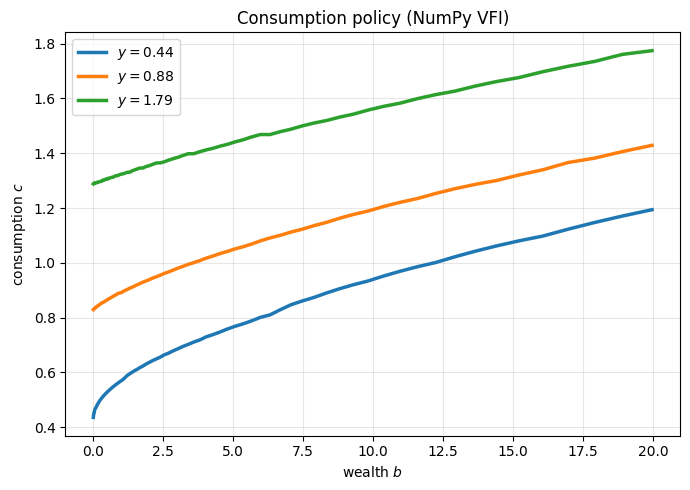

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
mask = b_grid <= 20
for j in range(n_y):
    ax.plot(b_grid[mask], c_policy[mask, j], lw=2.5, label=f"$y = {e_grid[j]:.2f}$")
ax.set_xlabel("wealth $b$")
ax.set_ylabel("consumption $c$")
ax.set_title("Consumption policy (NumPy VFI)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Save the reference solution

Notebooks 1 and 2 solve this exact problem with JAX and with the policy
gradient, and check that they reproduce this policy. We save it so they can
overlay against it.

In [5]:
import os

_here = os.path.dirname(__file__) if "__file__" in globals() else "."
ref_path = os.path.join(_here, "data", "nb0_reference.npz")
os.makedirs(os.path.dirname(ref_path), exist_ok=True)
np.savez(ref_path, b_grid=b_grid, e_grid=e_grid, Pi=Pi, c_policy=c_policy, V=V,
         sigma=sigma, beta=beta, q=q)
print("saved reference solution to", ref_path)

saved reference solution to ./data/nb0_reference.npz


## Exercises

1. **Risk aversion.** Re-solve with $\sigma = 1$ (log utility) and $\sigma = 5$.
   Higher $\sigma$ strengthens the precautionary-saving motive, so households
   consume less and save more at low wealth. A worked solution is below.
2. **Borrowing.** Allow borrowing by extending the asset grid below zero. Where
   does the policy change most, and why? (At low wealth, where the constraint
   binds.)

VFI converged in 921 iterations
VFI converged in 1036 iterations
VFI converged in 1012 iterations


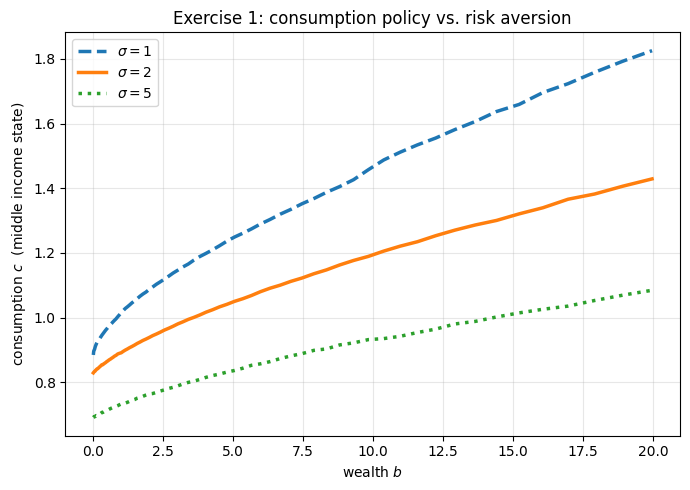

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for s, style in [(1.0, "--"), (2.0, "-"), (5.0, ":")]:
    _, c_s = solve_vfi(sig=s)
    ax.plot(b_grid[mask], c_s[mask, 1], style, lw=2.5, label=f"$\\sigma = {s:.0f}$")
ax.set_xlabel("wealth $b$")
ax.set_ylabel("consumption $c$  (middle income state)")
ax.set_title("Exercise 1: consumption policy vs. risk aversion")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()